In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def cost(x,t, lam = 1.0, I=None):
    k = len(x)
    if I is None:
        I = np.arange(k)        
    w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
    w_ = np.empty_like(w)
    w_[I] = w
    dim_cost = []
    for i in range(k):
        ell = 1/(w_[i]*(t*lam)+1)
        f_x_t = ell*np.exp(-(np.abs(x[i])*ell))
        dim_cost.append(1-f_x_t)
    return np.prod(np.array(dim_cost))

In [3]:
def generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1, num_x=30, num_y=30):
    x = np.linspace(x_min, x_max, num_x)
    y = np.linspace(y_min, y_max, num_y)
    xx, yy = np.meshgrid(x, y)
    points = np.vstack([xx.ravel(), yy.ravel()]).T

    return points

def plot_contour(X, Z, ax = None):
    x_unique = np.unique(X[:, 0])
    y_unique = np.unique(X[:, 1])
    X_grid = x_unique
    Y_grid = y_unique

    # Reshape Z to match mesh shape
    Z_grid = Z.reshape(len(y_unique), len(x_unique))  # Note: y first, x second due to row-major order

    # Create contour plot
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = plt.gcf()
    mappable = ax.contourf(X_grid, Y_grid, Z_grid, cmap='coolwarm')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.ax.set_ylabel(r'cost')
    cbar.set_label('cost')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.tight_layout()

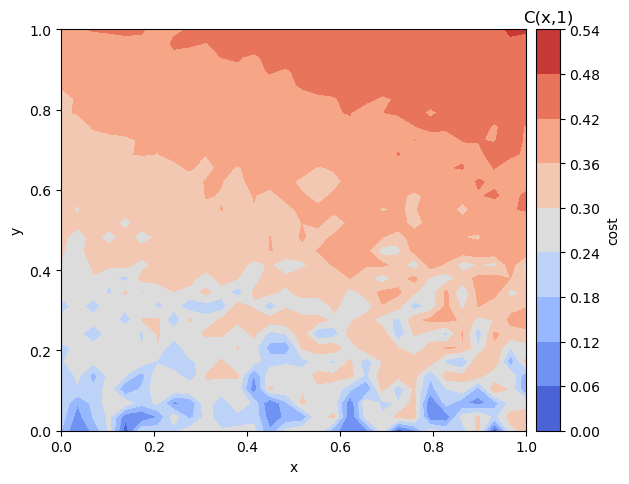

In [4]:
mesh_points = generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1)
cost_values = np.asarray([cost(p, 1, lam = 2, I = [1,0]) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,1)')
plt.show()


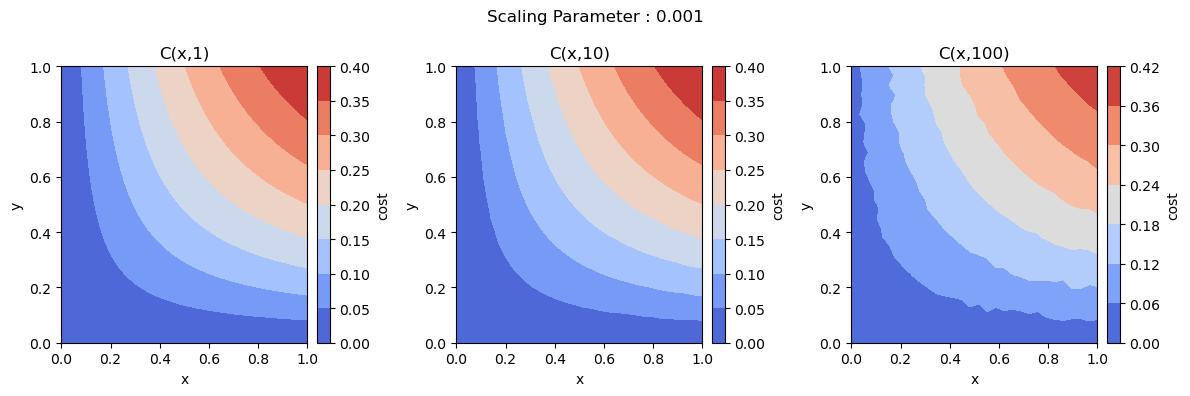

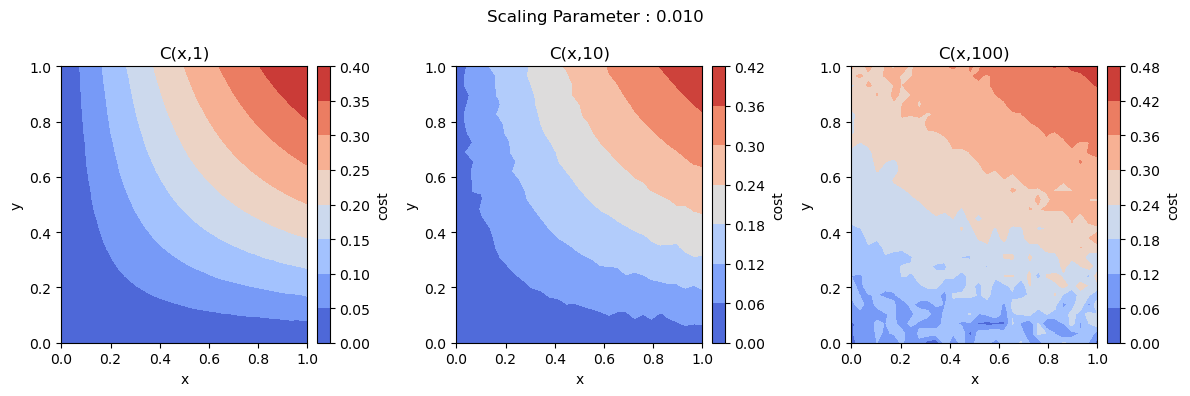

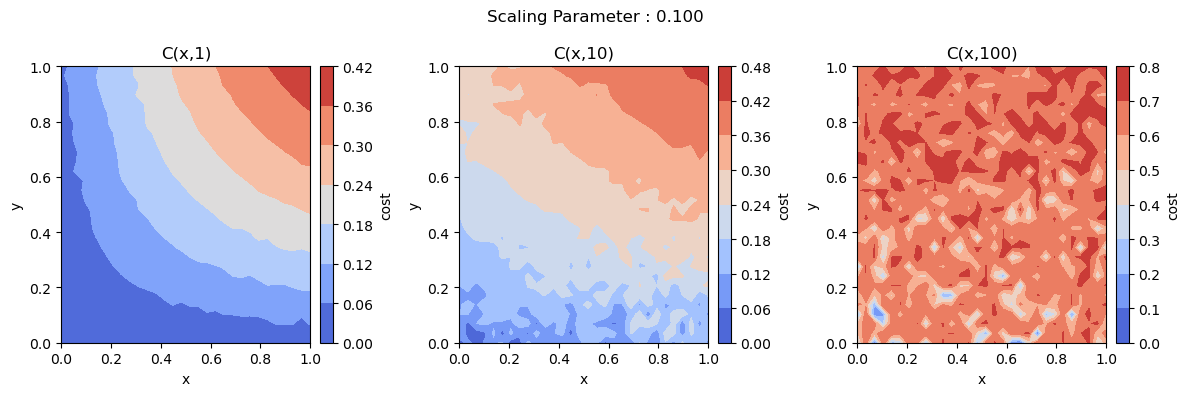

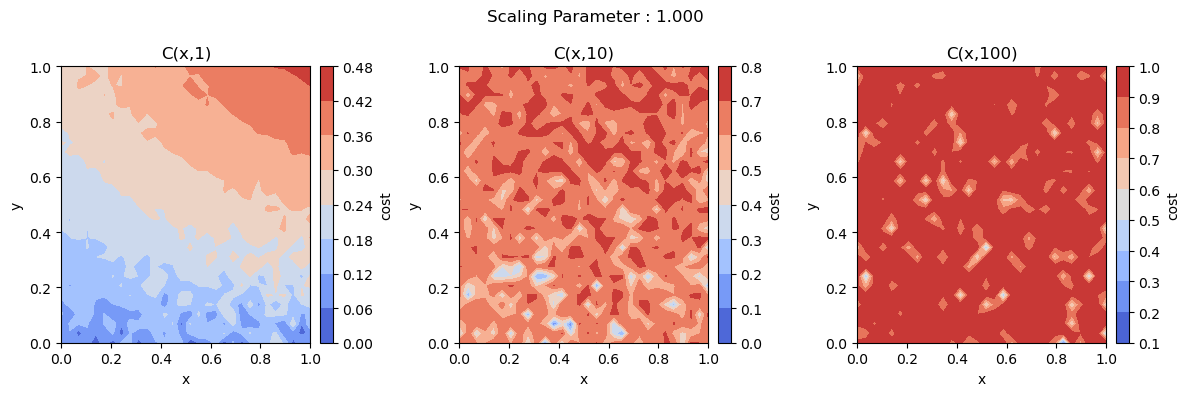

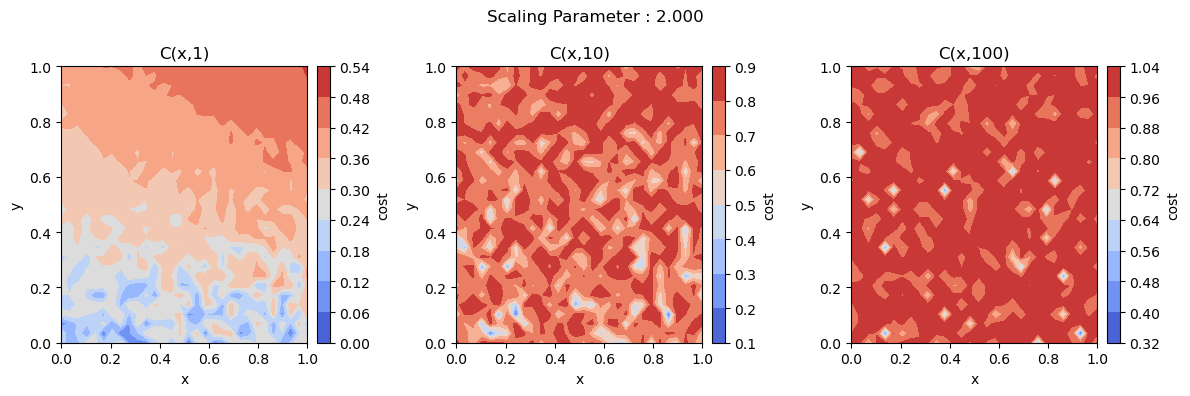

In [5]:
mesh_points = generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1)
for l in [0.001, 0.01, 0.1, 1, 2]:
    fig, axs = plt.subplots(1, 3, figsize=(4*3, 4*1))
    fig.suptitle("Scaling Parameter : %.3f"%l)
    axs = axs.flatten()
    for i, itr in enumerate([1,10,100]):
        cost_values = np.asarray([cost(p, itr, lam = l, I = [1,0]) for p in mesh_points])
        plot_contour(mesh_points, cost_values, ax = axs[i])
        axs[i].set_title('C(x,%d)'%itr)
    plt.show()

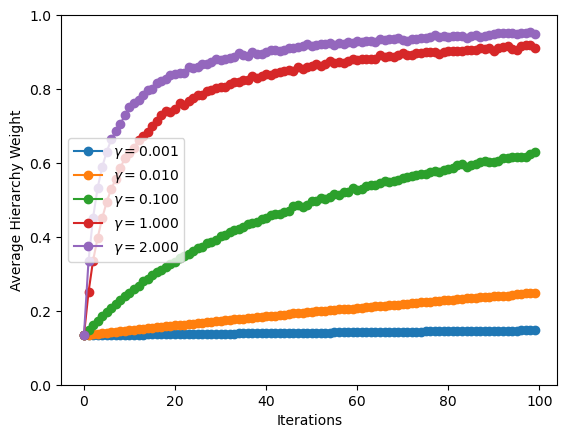

In [15]:
mesh_points = generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1)
fig, ax = plt.subplots()
for gamma in [0.001, 0.01, 0.1, 1, 2]:
    cost_mean = []
    for itr in range(100):
        cost_values = np.asarray([cost(p, itr, lam = gamma, I = [1,0]) for p in mesh_points])
        cost_mean.append(cost_values.sum()/len(mesh_points))
    ax.plot(np.arange(100), cost_mean, '-o', label=r"$\gamma=%.3f$"%gamma)    
ax.legend()
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("Iterations")
ax.set_ylabel("Average Hierarchy Weight")
plt.show()

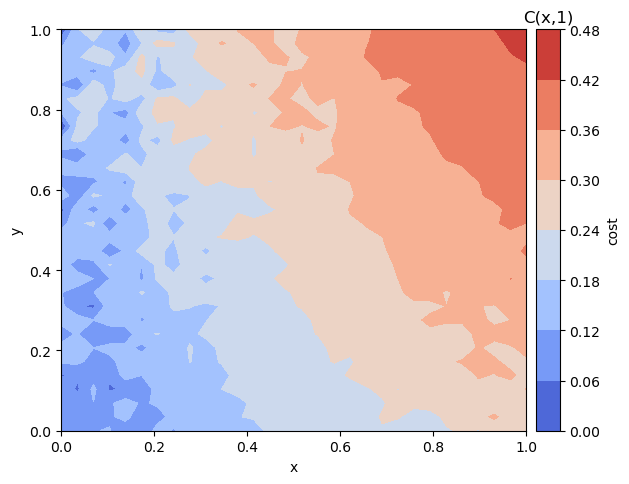

In [6]:
cost_values = np.asarray([cost(p, 1, I = [0,1]) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,1)')
plt.show()

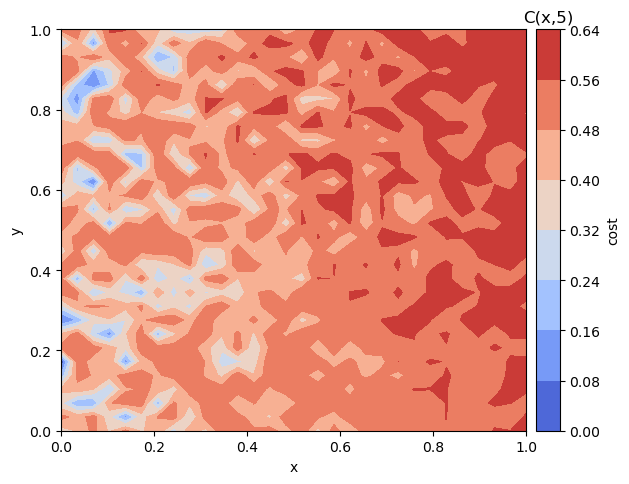

In [7]:
cost_values = np.asarray([cost(p, 5) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,5)')
plt.show()

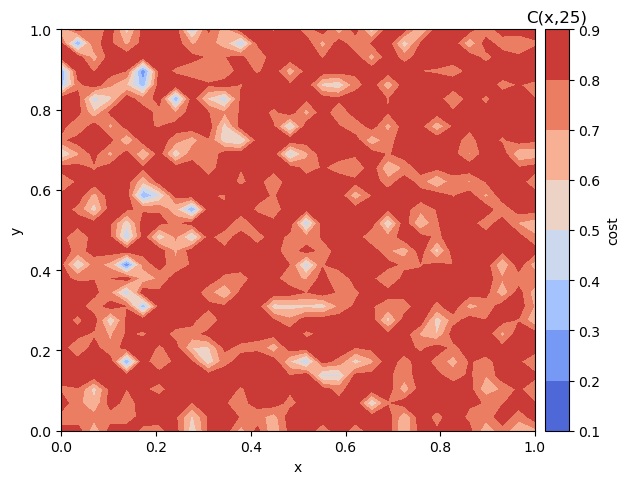

In [8]:
cost_values = np.asarray([cost(p, 25) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,25)')
plt.show()

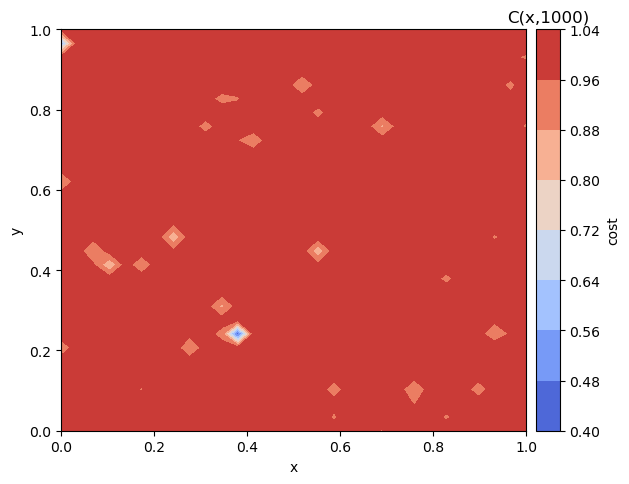

In [9]:
cost_values = np.asarray([cost(p, 1000) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,1000)')
plt.show()